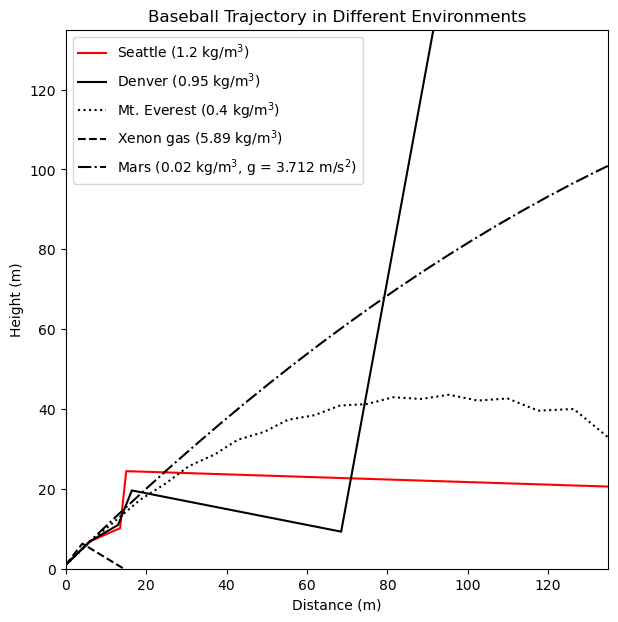

In [1]:
import trajectory_calculation as tr
import air_densities as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

v = 45  # m/s
omega = 150  # rad/s
rho = 1.2  # kg/m^3
axis = 0  # rad, pure backspin
angle = np.pi/4  # rad (30 deg)
step = 0.2  # s

plt.figure(figsize=(7,7))
tr.trajectory(v, omega, 1.2, angle, axis, step, label='Seattle', color='r', linestyle='-', savefig=False)
tr.trajectory(v, omega, 0.95, angle, axis, step, label='Denver', color='k', linestyle='-', savefig=False)
tr.trajectory(v, omega, 0.4, angle, axis, step, label='Mt. Everest', color='k', linestyle=':', savefig=False)
tr.trajectory(v, omega, 5.89, angle, axis, step, label='Xenon gas', color='k', linestyle='--', savefig=False)
tr.trajectory(v, omega, 0.02, angle, axis, step, label='Mars', color='k', linestyle='-.', g=3.712, savefig=False)

plt.title('Baseball Trajectory in Different Environments')
plt.xlim(0, 135)
plt.ylim(0, 135)
plt.savefig('trajectory_plot.png', bbox_inches = 'tight')
plt.show()

In [6]:
df = pd.read_csv('../ancillary_data/stadium_data.csv')
lons = df['longitude']
lats = df['latitude']
stadiums = df['stadium']
ids = df['venue_id']

output = []

for lon, lat, stadium, id in zip(lons, lats, stadiums, ids):
    d = {}
    T = ad.average_temp(lon, lat, venue_id=id)
    e = ad.elevation(lon, lat)
    rho = ad.density(T, e, 0.0289647)
    d['stadium'] = stadium
    d['rho'] = rho
    output.append(d)

df2 = pd.DataFrame(output)
df2

/Users/brodiemonohan/Desktop/School/University of Washington/Data Programming II/Git/Final Project/atmosphere_effects/air_densities.py:105: RuntimeWarning: Mean of empty slice.
  return ts.mean() + 274.15
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,stadium,rho
0,Chase Field,1.093952
1,Truist Park,1.133343
2,Sutter Health Park,1.170981
3,Camden Yards,1.180320
4,Fenway Park,1.201045
5,Wrigley Field,1.174307
6,Rate Field,1.171430
7,Great American Ball Park,1.160451
8,Progressive Field,1.174376
9,Coors Field,0.978823


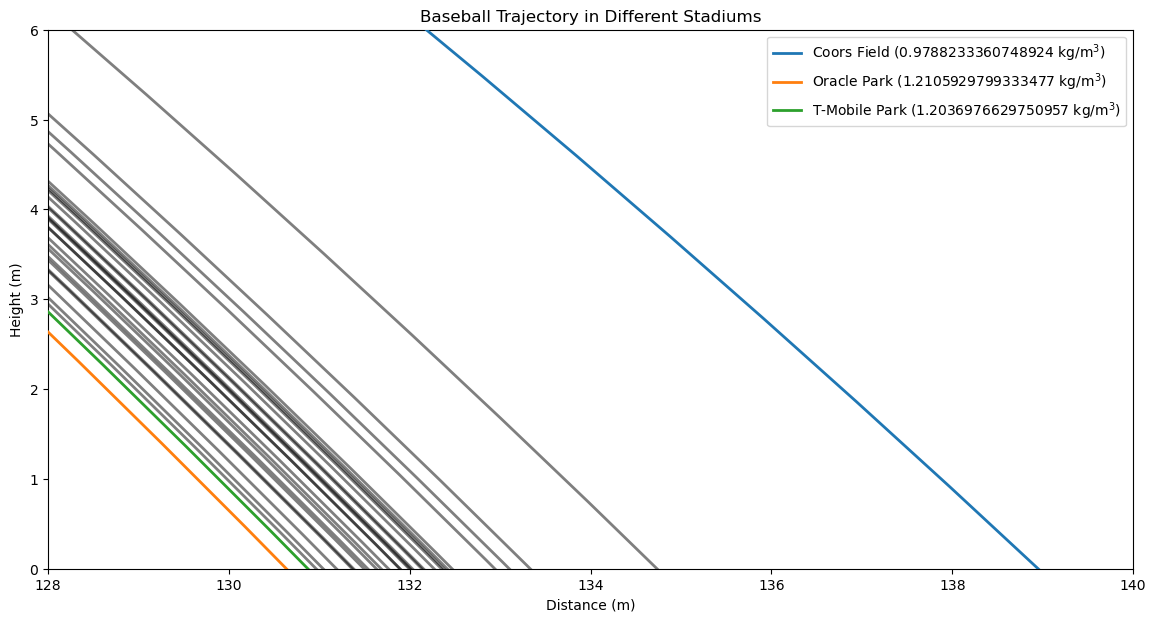

In [7]:
mark = ['T-Mobile Park', 'Coors Field', 'Oracle Park']

v = 45  # m/s
omega = 150  # rad/s
axis = 0  # rad, pure backspin
angle = np.pi/6  # rad (45 deg)
step = 0.05  # s

plt.figure(figsize=(14, 7))

for i in df2.index:
    row = df2.loc[i]
    color = 'k'
    if row['stadium'] in mark:
        label = row['stadium']
        color = None
        legend = True
        zorder = 5
        alpha = 1
    else:
        label = '_'
        legend = False
        zorder = 0
        alpha = 0.5
    if row['rho'] != np.NaN:
        tr.trajectory(v, omega, row['rho'], angle, axis, step, color=color,
                      label=label, linestyle='-', savefig=False, legend=False,
                      zorder=zorder, alpha=alpha, lw=2)
plt.title('Baseball Trajectory in Different Stadiums')
plt.xlim(128, 140)
plt.ylim(0, 6)
plt.legend()
plt.savefig('full_trajectory_plot.png', bbox_inches = 'tight')
plt.show()

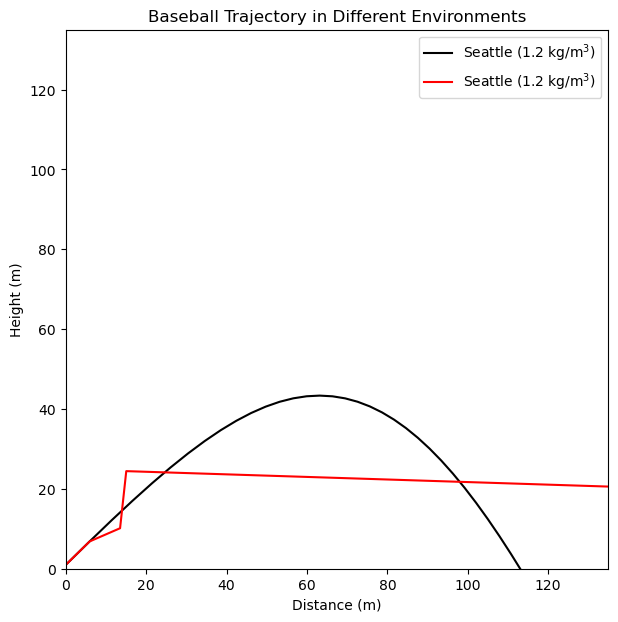

In [2]:
# with vs without spin-down
import trajectory_calculation as tr
import air_densities as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

v = 45  # m/s
omega = 150  # rad/s
rho = 1.2  # kg/m^3
axis = 0  # rad, pure backspin
angle = np.pi/4  # rad (30 deg)
step = 0.2  # s

plt.figure(figsize=(7,7))
tr.trajectory(v, omega, 1.2, angle, axis, step, label='Seattle', color='k', linestyle='-', savefig=False, sd=False)
tr.trajectory(v, omega, 1.2, angle, axis, step, label='Seattle', color='r', linestyle='-', savefig=False)

plt.title('Baseball Trajectory in Different Environments')
plt.xlim(0, 135)
plt.ylim(0, 135)
plt.savefig('trajectory_plot.png', bbox_inches = 'tight')
plt.show()